In [1]:
#Carga y limpieza de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from stepmix.stepmix import StepMix
from stepmix.utils import get_mixed_descriptor

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', message='.*did not converge.*')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = [12, 5]
RANDOM_STATE = 42

print('--- Iniciando Proceso de Segmentación (Versión Corregida) ---')
df_raw = pd.read_csv('s_order.csv')
print(f'Base de datos cargada: {df_raw.shape[0]:,} registros transaccionales, {df_raw.shape[1]} variables.')

df_cleaned = df_raw.copy()
df_cleaned['order_date'] = pd.to_datetime(df_cleaned['order_date'])
df_cleaned['hora'] = df_cleaned['order_time'].str[:2].astype(int)
df_cleaned['categoria_horario'] = np.select(
    [(df_cleaned['hora'] >= 6) & (df_cleaned['hora'] <= 11),
     (df_cleaned['hora'] >= 12) & (df_cleaned['hora'] <= 19)],
    ['Mañana', 'Tarde'], default='Madrugada'
)

fecha_corte = df_cleaned['order_date'].max() + pd.Timedelta(days=1)
df_clientes = df_cleaned.groupby('customer_id').agg(
    order_date=('order_date', lambda x: (fecha_corte - x.max()).days),
    order_id=('order_id', 'nunique'),
    total_spend=('total_spend', 'sum'),
    cart_size=('cart_size', 'mean'),
    customer_satisfaction=('customer_satisfaction', 'mean'),
    customer_age_group=('customer_age_group', 'first'),
    customer_gender=('customer_gender', 'first'),
    region=('region', 'first'),
    store_location_type=('store_location_type', 'first'),
    is_rewards_member=('is_rewards_member', 'first'),
    order_channel=('order_channel', lambda x: x.mode()[0])   # canal más frecuente por cliente
).reset_index()

df_clientes.rename(columns={
    'order_date': 'Recency',
    'order_id': 'Frequency',
    'total_spend': 'Monetary'
}, inplace=True)
df_clientes['is_rewards_member'] = df_clientes['is_rewards_member'].astype(int)

print(f'Limpieza finalizada. Base consolidada para {df_clientes.shape[0]:,} clientes únicos.')
df_clientes.head()

--- Iniciando Proceso de Segmentación (Versión Corregida) ---
Base de datos cargada: 100,000 registros transaccionales, 20 variables.


Limpieza finalizada. Base consolidada para 14,988 clientes únicos.


,customer_id,Recency,Frequency,Monetary,cart_size,customer_satisfaction,customer_age_group,customer_gender,region,store_location_type,is_rewards_member,order_channel
0,CUST_00001,41,12,174.60,3.666667,3.250000,35-44,Male,Southwest,Suburban,1,Drive-Thru
1,CUST_00002,62,13,207.18,4.076923,4.076923,25-34,Male,Midwest,Urban,0,Mobile App
2,CUST_00003,84,5,79.71,4.200000,3.400000,35-44,Female,Southwest,Rural,0,Mobile App
3,CUST_00004,146,7,95.85,3.571429,4.142857,45-54,Male,West,Rural,0,Drive-Thru
4,CUST_00005,80,3,47.45,4.666667,3.666667,25-34,Male,Northeast,Suburban,0,Drive-Thru



Dimensión final: 14,988 clientes × 12 variables
Período cubierto: 2024-01-01 a 2025-12-30

Valores faltantes por variable:
  → Sin valores faltantes en la base consolidada.

Descriptivos de variables RFM (escala original):


,Recency,Frequency,Monetary
count,14988.00,14988.00,14988.00
mean,108.59,6.67,99.19
std,105.03,2.56,40.97
min,1.00,1.00,3.83
25%,32.00,5.00,69.79
50%,76.00,6.00,95.60
75%,153.00,8.00,124.86
max,728.00,18.00,301.68


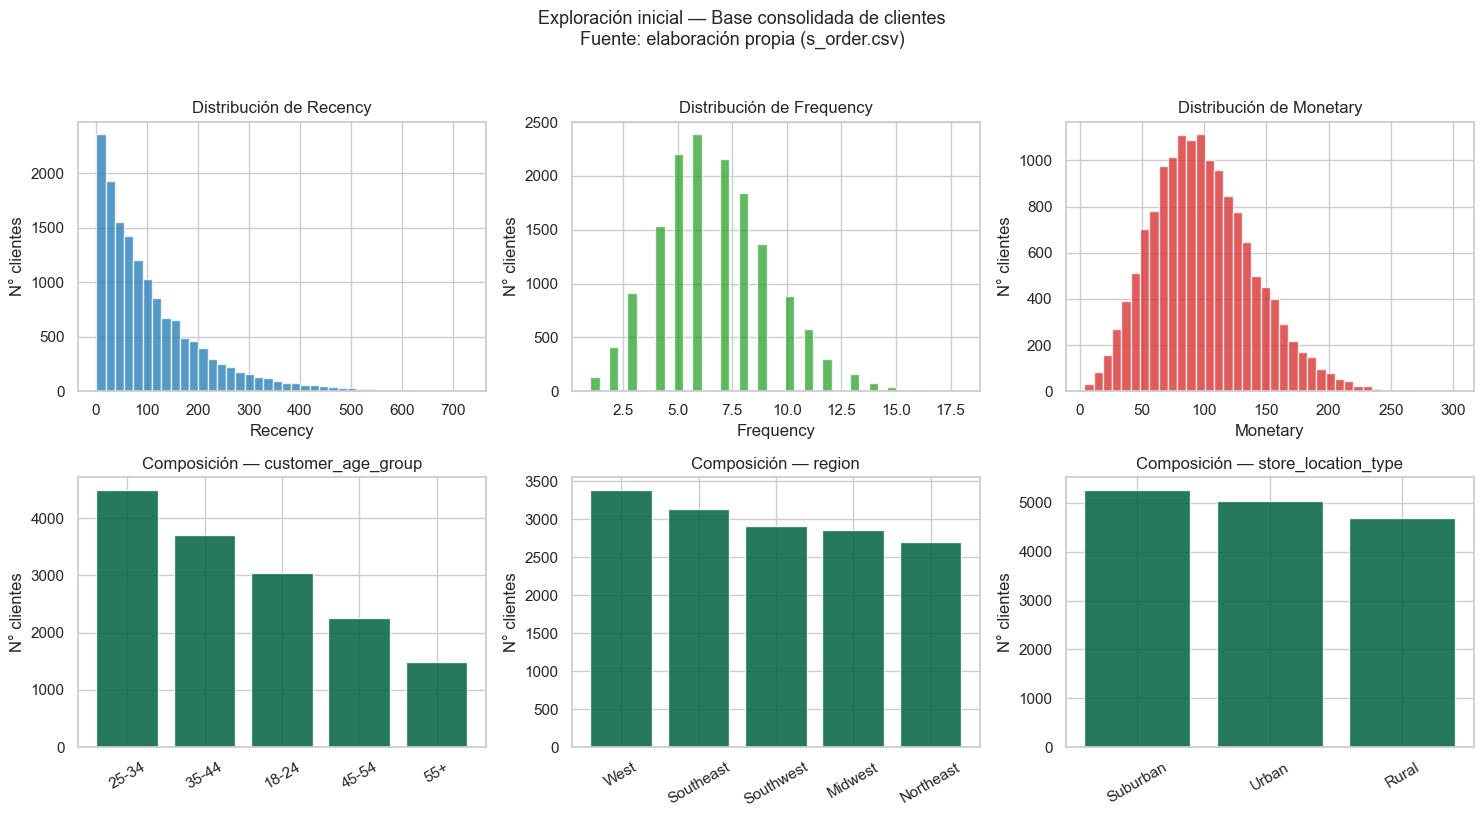


Tasa de membresía Rewards: 47.7%

Mix de canales (canal modal por cliente):
order_channel
Mobile App          47.7%
Drive-Thru          32.9%
In-Store Cashier    17.6%
Kiosk                1.8%
Name: proportion, dtype: object


In [2]:
# Exploración de los datos obtenidos post flitrado


print(f'\nDimensión final: {df_clientes.shape[0]:,} clientes × {df_clientes.shape[1]} variables')
print(f'Período cubierto: {df_cleaned["order_date"].min().date()} a {df_cleaned["order_date"].max().date()}')

print('\nValores faltantes por variable:')
missing = df_clientes.isna().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print('  → Sin valores faltantes en la base consolidada.')
else:
    print(missing)

print('\nDescriptivos de variables RFM (escala original):')
display(df_clientes[['Recency', 'Frequency', 'Monetary']].describe().round(2))

# Distribuciones visuales
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Histograma RFM
for ax, var, color in zip(axes[0], ['Recency', 'Frequency', 'Monetary'],
                           ['#1f77b4', '#2ca02c', '#d62728']):
    ax.hist(df_clientes[var], bins=40, color=color, alpha=0.75, edgecolor='white')
    ax.set_title(f'Distribución de {var}')
    ax.set_xlabel(var)
    ax.set_ylabel('N° clientes')

# Composición categórica
for ax, var in zip(axes[1], ['customer_age_group', 'region', 'store_location_type']):
    counts = df_clientes[var].value_counts()
    ax.bar(counts.index, counts.values, color='#006241', alpha=0.85, edgecolor='white')
    ax.set_title(f'Composición — {var}')
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylabel('N° clientes')

fig.suptitle('Exploración inicial — Base consolidada de clientes\nFuente: elaboración propia (s_order.csv)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Tasa de rewards y mix de canales
print('\nTasa de membresía Rewards: {:.1%}'.format(df_clientes['is_rewards_member'].mean()))
print('\nMix de canales (canal modal por cliente):')
print((df_clientes['order_channel'].value_counts(normalize=True) * 100).round(1).astype(str) + '%')


In [3]:
#1ER MODELO, SOCIODEMGRAFICO CON KMEANS
vars_bin_sd  = ['is_rewards_member']
vars_cat_sd  = ['customer_age_group', 'customer_gender', 'region',
                'store_location_type', 'order_channel']

df_sd = df_clientes[vars_bin_sd + vars_cat_sd].copy()

scaler  = StandardScaler()
X_num   = scaler.fit_transform(df_sd[vars_bin_sd])
X_num   = pd.DataFrame(X_num, columns=vars_bin_sd, index=df_sd.index)
X_cat   = pd.get_dummies(df_sd[vars_cat_sd], drop_first=False).astype(float)
X_km    = pd.concat([X_num, X_cat], axis=1)

print(f'Matriz K-Means Sociodemográfico: {X_km.shape}')
print(f'{X_num.shape[1]} variable(s) numérica(s) estandarizada(s)')
print(f'{X_cat.shape[1]} dummies de variables categóricas')

Matriz K-Means Sociodemográfico: (14988, 22)
1 variable(s) numérica(s) estandarizada(s)
21 dummies de variables categóricas


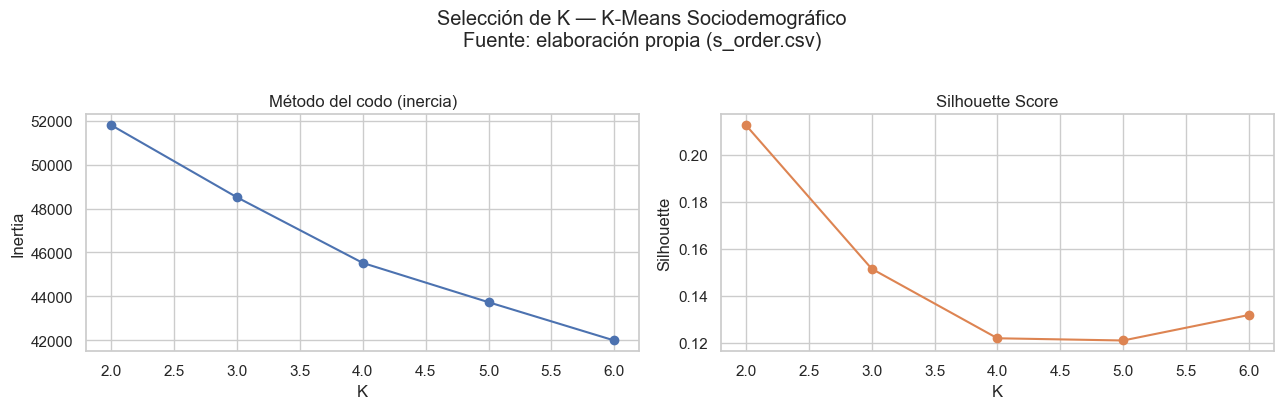

,K,Inertia,Silhouette
0,2,51798.0704,0.2125
1,3,48510.1298,0.1515
2,4,45521.4517,0.1219
3,5,43731.9136,0.1210
4,6,41986.7749,0.1318


In [4]:
# Evaluación del K óptimo — Elbow + Silhouette
ks = range(2, 7)
inertias_km, silhouettes_km = [], []

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_km)
    inertias_km.append(km.inertia_)
    silhouettes_km.append(silhouette_score(X_km, labels, sample_size=5000, random_state=RANDOM_STATE))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(ks), inertias_km, marker='o', color='#4C72B0')
axes[0].set_title('Método del codo (inercia)')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')

axes[1].plot(list(ks), silhouettes_km, marker='o', color='#DD8452')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette')

fig.suptitle('Selección de K — K-Means Sociodemográfico\nFuente: elaboración propia (s_order.csv)', y=1.02)
plt.tight_layout()
plt.show()

resumen_km_socio = pd.DataFrame({'K': list(ks), 'Inertia': inertias_km,
                                  'Silhouette': silhouettes_km}).round(4)
resumen_km_socio

In [5]:
#Evidenciamos un codo en K = 3, además de poseer un valor alto en la gráfica de Silhouette; no abstante, este no será
#el modelo elegido para sociodemográfico
K_km_socio = 3
kmeans_socio = KMeans(n_clusters=int(K_km_socio), n_init=10, random_state=RANDOM_STATE)
df_clientes['Cluster_Socio_KM'] = kmeans_socio.fit_predict(X_km)
print(f'Distribución de clientes por clúster (K-Means Sociodemográfico):')
print(df_clientes['Cluster_Socio_KM'].value_counts().sort_index())

Distribución de clientes por clúster (K-Means Sociodemográfico):
Cluster_Socio_KM
0    7150
1    3534
2    4304
Name: count, dtype: int64


In [6]:
#2DO MODELO SOCIODMEOGRAFICO CON STEPMIX

vars_bin_lca = ['is_rewards_member']
vars_cat_lca = ['customer_age_group', 'customer_gender', 'region',
                'store_location_type', 'order_channel']

df_lca = df_clientes[vars_bin_lca + vars_cat_lca].copy()
df_lca['is_rewards_member'] = df_lca['is_rewards_member'].astype(int)

encoders = {}
for c in vars_cat_lca:
    le = LabelEncoder()
    df_lca[c] = le.fit_transform(df_lca[c])
    encoders[c] = le

measurement_spec = {
    'bin': {'model': 'binary',      'n_columns': len(vars_bin_lca)},
    'cat': {'model': 'categorical', 'n_columns': len(vars_cat_lca)},
}
cols_ordenadas = vars_bin_lca + vars_cat_lca
X_full_lca = df_lca[cols_ordenadas]

# Muestra para búsqueda de K (por tiempo de cómputo)
sample_size = min(3000, len(df_lca))
df_lca_sample = df_lca.sample(sample_size, random_state=RANDOM_STATE)
X_mixed_sample = df_lca_sample[cols_ordenadas]
print(f'Muestra para selección de K: {X_mixed_sample.shape}')

Muestra para selección de K: (3000, 6)


Buscando K óptimo para LCA Sociodemográfico...



K=2: BIC=41747.1 | AIC=41536.8 | Entropía=0.7041 (0.5s)


K=3: BIC=41832.5 | AIC=41514.2 | Entropía=0.5153 (0.4s)


K=4: BIC=41924.8 | AIC=41498.4 | Entropía=0.4727 (0.5s)


K=5: BIC=42031.1 | AIC=41496.5 | Entropía=0.4959 (0.5s)


K=6: BIC=42147.3 | AIC=41504.6 | Entropía=0.4763 (0.5s)


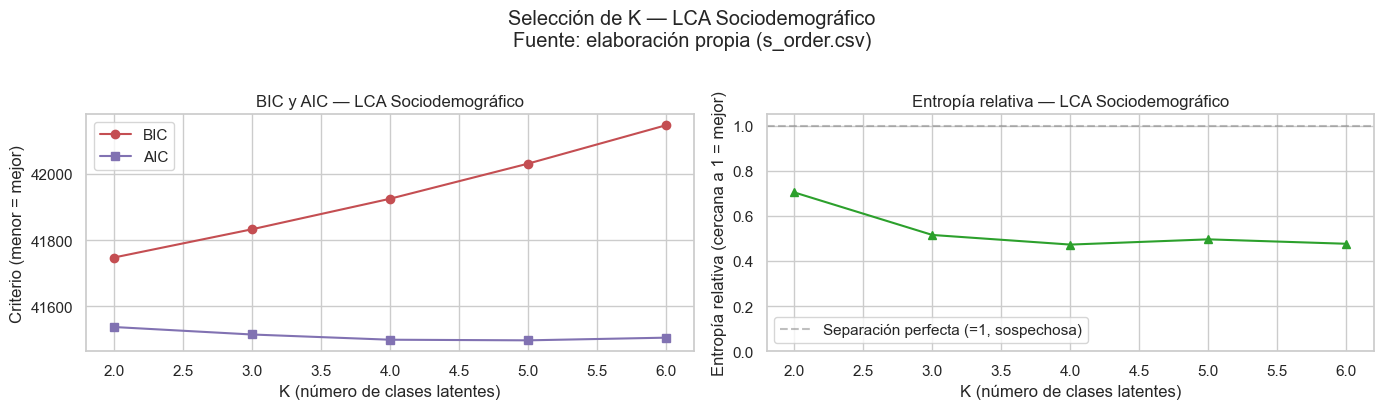

,K,BIC,AIC,Entropía relativa
0,2,41747.0526,41536.8298,0.7041
1,3,41832.5079,41514.1704,0.5153
2,4,41924.8204,41498.3683,0.4727
3,5,42031.0663,41496.4996,0.4959
4,6,42147.2786,41504.5973,0.4763


In [7]:
#Código diseñado con ayuda de ia (tabulación de entropía)
def calcular_entropia_relativa(model, X, k):
    """Entropía relativa: E = 1 - H_media / ln(K). Rango [0,1], cercano a 1 = buena separación."""
    if k <= 1:
        return np.nan
    probs = model.predict_proba(X)
    H = -np.sum(probs * np.log(probs + 1e-10), axis=1)  # entropía por individuo
    return 1 - H.mean() / np.log(k)

bics_lca, aics_lca, entropias_lca, ks_lca = [], [], [], list(range(2, 7))
print('Buscando K óptimo para LCA Sociodemográfico...\n')

for k in ks_lca:
    t0 = time.time()
    model = StepMix(n_components=k, measurement=measurement_spec,
                    n_init=2, max_iter=200, random_state=RANDOM_STATE,
                    verbose=0, progress_bar=0)
    model.fit(X_mixed_sample)
    bic = model.bic(X_mixed_sample)
    aic = model.aic(X_mixed_sample)
    ent = calcular_entropia_relativa(model, X_mixed_sample, k)
    bics_lca.append(bic)
    aics_lca.append(aic)
    entropias_lca.append(ent)
    print(f'K={k}: BIC={bic:.1f} | AIC={aic:.1f} | Entropía={ent:.4f} ({time.time()-t0:.1f}s)')

# Gráficos diagnósticos
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(ks_lca, bics_lca, marker='o', label='BIC', color='#C44E52')
axes[0].plot(ks_lca, aics_lca, marker='s', label='AIC', color='#8172B2')
axes[0].set_xlabel('K (número de clases latentes)')
axes[0].set_ylabel('Criterio (menor = mejor)')
axes[0].set_title('BIC y AIC — LCA Sociodemográfico')
axes[0].legend()


axes[1].plot(ks_lca, entropias_lca, marker='^', color='#2ca02c')
axes[1].axhline(y=1.0, linestyle='--', color='gray', alpha=0.5, label='Separación perfecta (=1, sospechosa)')
axes[1].set_xlabel('K (número de clases latentes)')
axes[1].set_ylabel('Entropía relativa (cercana a 1 = mejor)')
axes[1].set_title('Entropía relativa — LCA Sociodemográfico')
axes[1].set_ylim(0, 1.05)
axes[1].legend()

fig.suptitle('Selección de K — LCA Sociodemográfico\nFuente: elaboración propia (s_order.csv)', y=1.02)
plt.tight_layout()
plt.show()

resumen_lca_socio = pd.DataFrame({
    'K': ks_lca, 'BIC': bics_lca, 'AIC': aics_lca, 'Entropía relativa': entropias_lca
}).round(4)
resumen_lca_socio

In [8]:
#Mediante la función obtenemos originalmente K = 2, pero bajo el contexto del trabajo, denegaremos esa opción, y nos 
#quedaremos con la segunda mejor alternativa, K = 3
# Selección automática del K que minimiza el BIC
K_lca_optimo = 3
entropia_optima = entropias_lca[ks_lca.index(K_lca_optimo)]

print(f'K óptimo según BIC: K = {K_lca_optimo}')
print(f'  BIC en K={K_lca_optimo}: {min(bics_lca):.1f}')
print(f'  Entropía relativa en K={K_lca_optimo}: {entropia_optima:.4f}')
print()
print('Justificación: Se selecciona el K que minimiza el BIC (mejor ajuste penalizado por complejidad).')
print('Se verifica que la entropía relativa sea cercana a 1 pero no exactamente 1.')
if entropia_optima < 0.5:
    print(f'Entropía={entropia_optima:.3f} < 0.5 → clasificación ambigua. Considerar K menor.')

# Ajuste final sobre la BASE COMPLETA con el k óptimo
lca_socio_final = StepMix(n_components=K_lca_optimo, measurement=measurement_spec,
                           n_init=3, max_iter=300, random_state=RANDOM_STATE,
                           verbose=0, progress_bar=0)
lca_socio_final.fit(X_full_lca)
df_clientes['Cluster_Socio_LCA'] = lca_socio_final.predict(X_full_lca)

probs_socio = lca_socio_final.predict_proba(X_full_lca)
df_clientes['LCA_Socio_Prob_Max'] = probs_socio.max(axis=1)

# CORRECCIÓN 1: entropía sobre la base completa
H_full = -np.sum(probs_socio * np.log(probs_socio + 1e-10), axis=1)
entropia_full_socio = 1 - H_full.mean() / np.log(K_lca_optimo)

print(f'Distribución de clientes por clúster:')
print(df_clientes['Cluster_Socio_LCA'].value_counts().sort_index())
print(f'Entropía relativa (base completa): {entropia_full_socio:.4f}')
print(f'Probabilidad de pertenencia mediana: {df_clientes["LCA_Socio_Prob_Max"].median():.2f}')
print(f'Clientes borderline (prob. máx. < 0.6): {(df_clientes["LCA_Socio_Prob_Max"] < 0.6).sum()}')

K óptimo según BIC: K = 3
  BIC en K=3: 41747.1
  Entropía relativa en K=3: 0.5153

Justificación: Se selecciona el K que minimiza el BIC (mejor ajuste penalizado por complejidad).
Se verifica que la entropía relativa sea cercana a 1 pero no exactamente 1.


Distribución de clientes por clúster:
Cluster_Socio_LCA
0    2677
1    8951
2    3360
Name: count, dtype: int64
Entropía relativa (base completa): 0.5530
Probabilidad de pertenencia mediana: 0.82
Clientes borderline (prob. máx. < 0.6): 3593



--- customer_age_group ---


customer_age_group,18-24,25-34,35-44,45-54,55+
Cluster_Socio_LCA,,,,,
0,1.0,1.1,61.2,36.7,0.0
1,31.3,46.1,13.6,8.8,0.2
2,6.5,9.9,25.5,14.4,43.7



--- customer_gender ---


customer_gender,Female,Male,Non-binary,Prefer not to say
Cluster_Socio_LCA,,,,
0,45.6,46.5,3.0,4.8
1,46.0,43.9,5.3,4.8
2,43.8,45.4,6.0,4.9



--- region ---


...

store_location_type,Rural,Suburban,Urban
Cluster_Socio_LCA,,,
0,33.4,35.1,31.6
1,31.0,35.0,34.0
2,30.6,35.2,34.2



--- order_channel ---


order_channel,Drive-Thru,In-Store Cashier,Kiosk,Mobile App
Cluster_Socio_LCA,,,,
0,91.0,0.0,9.0,0.0
1,20.1,0.0,0.0,79.9
2,20.8,78.4,0.8,0.0



--- is_rewards_member ---


is_rewards_member,0,1
Cluster_Socio_LCA,,
0,57.3,42.7
1,47.9,52.1
2,59.9,40.1


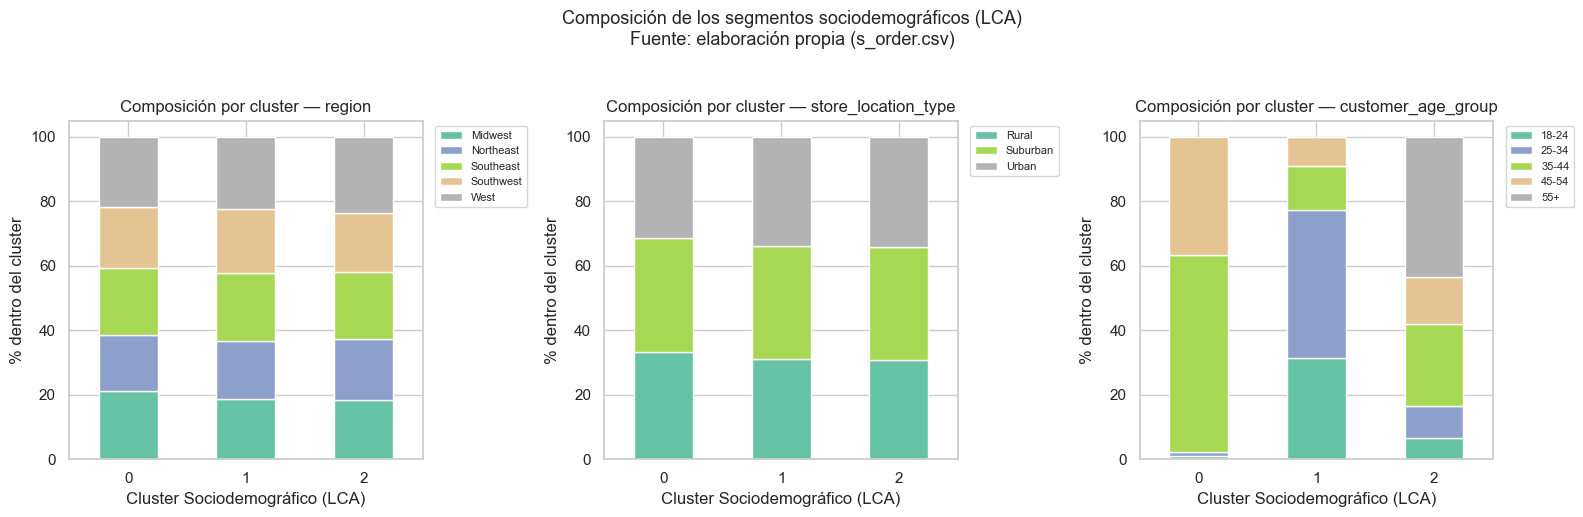

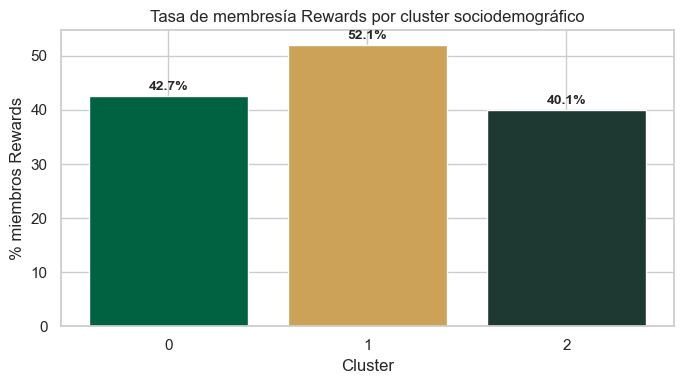

In [9]:
# Caracterización cualitativa de cada cluster sociodemográfico (LCA)
vars_socio_perfil = ['customer_age_group', 'customer_gender', 'region',
                     'store_location_type', 'order_channel', 'is_rewards_member']

for var in vars_socio_perfil:
    print(f'\n--- {var} ---')
    tabla = pd.crosstab(df_clientes['Cluster_Socio_LCA'], df_clientes[var],
                        normalize='index') * 100
    display(tabla.round(1))

# Visualización: barras apiladas por cluster para las tres variables más informativas
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, var in zip(axes, ['region', 'store_location_type', 'customer_age_group']):
    tabla = pd.crosstab(df_clientes['Cluster_Socio_LCA'], df_clientes[var],
                        normalize='index') * 100
    tabla.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='white')
    ax.set_title(f'Composición por cluster — {var}')
    ax.set_xlabel('Cluster Sociodemográfico (LCA)')
    ax.set_ylabel('% dentro del cluster')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    ax.tick_params(axis='x', rotation=0)

fig.suptitle('Composición de los segmentos sociodemográficos (LCA)\nFuente: elaboración propia (s_order.csv)',
             y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

# Tasa de rewards por cluster (variable binaria, se grafica aparte)
fig, ax = plt.subplots(figsize=(7, 4))
rewards_pct = df_clientes.groupby('Cluster_Socio_LCA')['is_rewards_member'].mean() * 100
bars = ax.bar(rewards_pct.index.astype(str), rewards_pct.values,
              color=['#006241', '#cba258', '#1e3932'], edgecolor='white')
ax.set_title('Tasa de membresía Rewards por cluster sociodemográfico')
ax.set_xlabel('Cluster')
ax.set_ylabel('% miembros Rewards')
for bar, val in zip(bars, rewards_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%',
            ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


--- Evaluando Dimensión Conductual RFM: K-Means ---


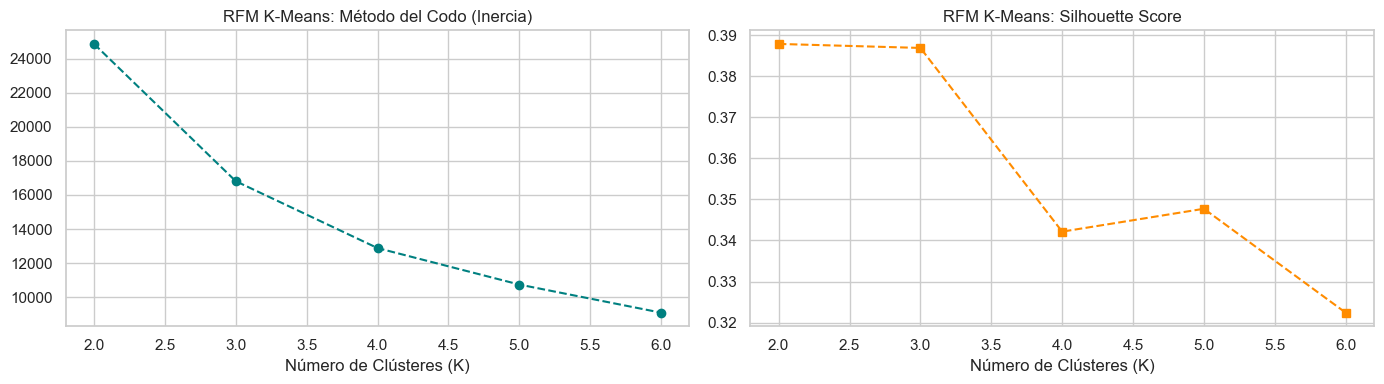

,K,Inertia,Silhouette
0,2,24866.3110,0.3879
1,3,16807.0850,0.3869
2,4,12881.0665,0.3421
3,5,10739.5148,0.3477
4,6,9089.7764,0.3224


In [10]:
#3ER MODELO KMEANS

print('--- Evaluando Dimensión Conductual RFM: K-Means ---')
X_rfm_scaled = StandardScaler().fit_transform(df_clientes[['Recency', 'Frequency', 'Monetary']])

rfm_inertia, rfm_silhouette_km = [], []
for k in ks:
    km_rfm = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_rfm = km_rfm.fit_predict(X_rfm_scaled)
    rfm_inertia.append(km_rfm.inertia_)
    rfm_silhouette_km.append(silhouette_score(X_rfm_scaled, labels_rfm,
                                               sample_size=5000, random_state=RANDOM_STATE))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(list(ks), rfm_inertia, marker='o', color='teal', linestyle='--')
ax[0].set_title('RFM K-Means: Método del Codo (Inercia)')
ax[0].set_xlabel('Número de Clústeres (K)')
ax[1].plot(list(ks), rfm_silhouette_km, marker='s', color='darkorange', linestyle='--')
ax[1].set_title('RFM K-Means: Silhouette Score')
ax[1].set_xlabel('Número de Clústeres (K)')
plt.tight_layout()
plt.show()

resumen_rfm_km = pd.DataFrame({'K': list(ks), 'Inertia': rfm_inertia,
                                 'Silhouette': rfm_silhouette_km}).round(4)
resumen_rfm_km

In [11]:
#En el gráfico, podemos observar que el codo se ubica en torno a K=3, además este posee el 2do valor de Silhouette
#más alto, siendo el primero K= 2 pero bajo el contexto de análisis del trabajo descartamos esa opción.
#Dentro del análisis RFM, el modelo con Kmeans será el elegido
K_rfm_km_optimo = 3
km_rfm_final = KMeans(n_clusters=K_rfm_km_optimo, n_init=10, random_state=RANDOM_STATE)
df_clientes['Cluster_RFM_KM'] = km_rfm_final.fit_predict(X_rfm_scaled)

# Perfil RFM por cluster (medias en escala original, no escaladas)
perfil_rfm_km = df_clientes.groupby('Cluster_RFM_KM')[['Recency','Frequency','Monetary']].mean().round(2)
perfil_rfm_km.columns = ['Recency (días)', 'Frequency (n° órdenes)', 'Monetary (gasto total $)']
perfil_rfm_km['N clientes'] = df_clientes['Cluster_RFM_KM'].value_counts().sort_index().values

print('\nPerfil RFM por clúster (K-Means, escala original):')
display(perfil_rfm_km)


Perfil RFM por clúster (K-Means, escala original):


,Recency (días),Frequency (n° órdenes),Monetary (gasto total $),N clientes
Cluster_RFM_KM,,,,
0,296.92,4.18,61.22,2344
1,70.37,9.40,142.75,5254
2,76.03,5.52,80.27,7390


  K              BIC              AIC    Entropía   Tiempo
----------------------------------------------------------


K=2: BIC=122469.1 | AIC=122415.8 | Entropía=0.5272 (2.2s)


K=3: BIC=119844.2 | AIC=119760.4 | Entropía=0.7251 (2.0s)


K=4: BIC=119741.2 | AIC=119627.0 | Entropía=0.6659 (6.4s)


K=5: BIC=119779.3 | AIC=119634.6 | Entropía=0.4457 (7.4s)


K=6: BIC=119817.1 | AIC=119642.0 | Entropía=0.3545 (8.6s)


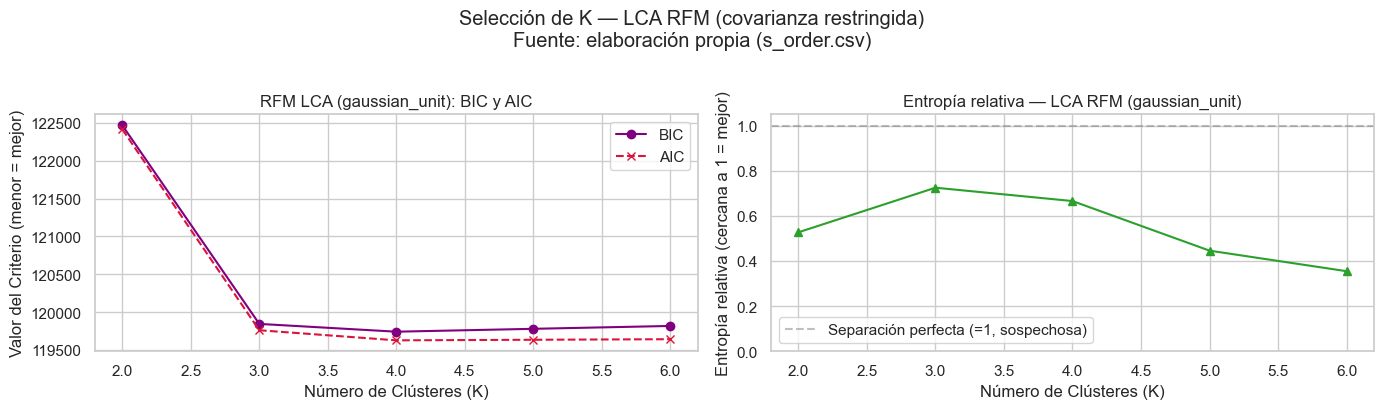

,K,BIC,AIC,Entropía relativa
0,2,122469.1338,122415.8288,0.5272
1,3,119844.2030,119760.4379,0.7251
2,4,119741.1874,119626.9623,0.6659
3,5,119779.2514,119634.5663,0.4457
4,6,119817.1051,119641.9600,0.3545


In [12]:
#Como trabajamos con variables numéricas estandarizadas, no es recomendable utilizar Stepmix, por lo que descartaremos
#este método para el análisis RFM.
#4TO MODELO, RFM CON STEPMIX
# Estandarización previa: necesaria para gaussian_unit (varianza fija en 1)
scaler_rfm = StandardScaler()
df_rfm_scaled = pd.DataFrame(
    scaler_rfm.fit_transform(df_clientes[['Recency', 'Frequency', 'Monetary']]),
    columns=['Recency', 'Frequency', 'Monetary']
)

# Descriptor con covarianza esférica unitaria (no estima varianzas libremente)
mixed_data_rfm, mixed_desc_rfm = get_mixed_descriptor(
    dataframe=df_rfm_scaled,
    gaussian_unit=['Recency', 'Frequency', 'Monetary']
)

rfm_bic, rfm_aic, rfm_entropia = [], [], []
print(f'{"K":>3}  {"BIC":>15}  {"AIC":>15}  {"Entropía":>10}  {"Tiempo":>7}')
print('-' * 58)

for k in ks:
    t0 = time.time()
    lca_rfm = StepMix(n_components=k, measurement=mixed_desc_rfm,
                      n_init=5, max_iter=300,
                      random_state=RANDOM_STATE, verbose=0, progress_bar=0)
    lca_rfm.fit(mixed_data_rfm)
    bic = lca_rfm.bic(mixed_data_rfm)
    aic = lca_rfm.aic(mixed_data_rfm)
    ent = calcular_entropia_relativa(lca_rfm, mixed_data_rfm, k)
    rfm_bic.append(bic)
    rfm_aic.append(aic)
    rfm_entropia.append(ent)
    print(f'K={k}: BIC={bic:.1f} | AIC={aic:.1f} | Entropía={ent:.4f} ({time.time()-t0:.1f}s)')

# Gráficos diagnósticos
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(list(ks), rfm_bic, marker='o', label='BIC', color='purple', linestyle='-')
axes[0].plot(list(ks), rfm_aic, marker='x', label='AIC', color='crimson', linestyle='--')
axes[0].set_title('RFM LCA (gaussian_unit): BIC y AIC')
axes[0].set_xlabel('Número de Clústeres (K)')
axes[0].set_ylabel('Valor del Criterio (menor = mejor)')
axes[0].legend()

axes[1].plot(list(ks), rfm_entropia, marker='^', color='#2ca02c')
axes[1].axhline(y=1.0, linestyle='--', color='gray', alpha=0.5,
                label='Separación perfecta (=1, sospechosa)')
axes[1].set_xlabel('Número de Clústeres (K)')
axes[1].set_ylabel('Entropía relativa (cercana a 1 = mejor)')
axes[1].set_title('Entropía relativa — LCA RFM (gaussian_unit)')
axes[1].set_ylim(0, 1.05)
axes[1].legend()

fig.suptitle('Selección de K — LCA RFM (covarianza restringida)\nFuente: elaboración propia (s_order.csv)', y=1.02)
plt.tight_layout()
plt.show()

resumen_lca_rfm = pd.DataFrame({
    'K': list(ks), 'BIC': rfm_bic, 'AIC': rfm_aic, 'Entropía relativa': rfm_entropia
}).round(4)
display(resumen_lca_rfm)


In [13]:
# Selección de K óptimo — LCA RFM (gaussian_unit)
K_rfm_lca_optimo = int(list(ks)[int(np.argmin(rfm_bic))])
entropia_rfm_optima = rfm_entropia[list(ks).index(K_rfm_lca_optimo)]

print(f'K óptimo LCA RFM (BIC mínimo): K = {K_rfm_lca_optimo}')
print(f'  BIC en K={K_rfm_lca_optimo}: {min(rfm_bic):.1f}')
print(f'  Entropía relativa en K={K_rfm_lca_optimo}: {entropia_rfm_optima:.4f}')
print()
print('Justificación: Se selecciona el K que minimiza el BIC.')
print('Con gaussian_unit la entropía ya no está degenerada y refleja')
print('la certeza real de clasificación del modelo.')
if entropia_rfm_optima < 0.5:
    print(f'⚠️  ADVERTENCIA: Entropía={entropia_rfm_optima:.3f} < 0.5 → clasificación ambigua.')
elif entropia_rfm_optima > 0.999:
    print(f'⚠️  ADVERTENCIA: Entropía={entropia_rfm_optima:.4f} ≈ 1 → posible degeneración residual.')
    print('    Verificar distribución de clientes por clúster y tamaño del clúster más pequeño.')

# Ajuste final sobre datos estandarizados (misma escala usada en búsqueda de K)
lca_rfm_final = StepMix(n_components=K_rfm_lca_optimo, measurement=mixed_desc_rfm,
                         n_init=5, max_iter=300,
                         random_state=RANDOM_STATE, verbose=0, progress_bar=0)
lca_rfm_final.fit(mixed_data_rfm)
df_clientes['Cluster_RFM_LCA'] = lca_rfm_final.predict(mixed_data_rfm)

# Probabilidades de pertenencia
probs_rfm = lca_rfm_final.predict_proba(mixed_data_rfm)
df_clientes['LCA_RFM_Prob_Max'] = probs_rfm.max(axis=1)

# Entropía sobre datos completos
H_rfm = -np.sum(probs_rfm * np.log(probs_rfm + 1e-10), axis=1)
entropia_full_rfm = 1 - H_rfm.mean() / np.log(K_rfm_lca_optimo)

# Perfil en ESCALA ORIGINAL (se invierten las transformaciones del scaler)
rfm_orig = df_clientes[['Recency', 'Frequency', 'Monetary']].copy()
perfil_rfm_lca = rfm_orig.groupby(df_clientes['Cluster_RFM_LCA']).mean().round(2)
perfil_rfm_lca.columns = ['Recency (días)', 'Frequency (n° órdenes)', 'Monetary (gasto total $)']
perfil_rfm_lca['N clientes'] = df_clientes['Cluster_RFM_LCA'].value_counts().sort_index().values
perfil_rfm_lca['% mercado'] = (perfil_rfm_lca['N clientes'] / len(df_clientes) * 100).round(1)

print('\nPerfil RFM por clúster (StepMix LCA gaussian_unit, escala original):')
display(perfil_rfm_lca)

print(f'\nEntropía relativa (base completa): {entropia_full_rfm:.4f}')
print(f'Probabilidad de pertenencia mediana: {df_clientes["LCA_RFM_Prob_Max"].median():.2f}')
print(f'Clientes borderline (prob. máx. < 0.6): {(df_clientes["LCA_RFM_Prob_Max"] < 0.6).sum()}')
print(f'Clúster más pequeño: {df_clientes["Cluster_RFM_LCA"].value_counts().min()} clientes')


K óptimo LCA RFM (BIC mínimo): K = 4
  BIC en K=4: 119741.2
  Entropía relativa en K=4: 0.6659

Justificación: Se selecciona el K que minimiza el BIC.
Con gaussian_unit la entropía ya no está degenerada y refleja
la certeza real de clasificación del modelo.



Perfil RFM por clúster (StepMix LCA gaussian_unit, escala original):


,Recency (días),Frequency (n° órdenes),Monetary (gasto total $),N clientes,% mercado
Cluster_RFM_LCA,,,,,
0,430.89,3.05,44.97,624,4.2
1,107.12,5.63,82.18,10277,68.6
2,63.95,9.59,145.83,3822,25.5
3,50.66,13.59,214.15,265,1.8



Entropía relativa (base completa): 0.6659
Probabilidad de pertenencia mediana: 0.82
Clientes borderline (prob. máx. < 0.6): 1933
Clúster más pequeño: 265 clientes


In [14]:
#COMPARACIÓN MODELOS
print('--- Análisis Comparativo Multicriterio ---')

def safe_silhouette(X, labels):
    if len(np.unique(labels)) < 2:
        return np.nan
    return silhouette_score(X, labels, sample_size=3000, random_state=RANDOM_STATE)

def safe_db(X, labels):
    if len(np.unique(labels)) < 2:
        return np.nan
    return davies_bouldin_score(X, labels)



tabla_comp = pd.DataFrame({
    'K elegido': [K_km_socio, K_lca_optimo, K_rfm_km_optimo, K_rfm_lca_optimo],
    'Criterio K': ['Elbow + Silhouette', 'BIC mínimo + Entropía', 'Elbow + Silhouette', 'BIC mínimo + Entropía'],
    'Silhouette (*aprox. LCA)': [
        round(safe_silhouette(X_km, df_clientes['Cluster_Socio_KM']), 3),
        round(safe_silhouette(X_km, df_clientes['Cluster_Socio_LCA']), 3),   # aprox.
        round(safe_silhouette(X_rfm_scaled, df_clientes['Cluster_RFM_KM']), 3),
        round(safe_silhouette(X_rfm_scaled, df_clientes['Cluster_RFM_LCA']), 3),  # aprox.
    ],
    'Davies-Bouldin (*aprox. LCA)': [
        round(safe_db(X_km, df_clientes['Cluster_Socio_KM']), 3),
        round(safe_db(X_km, df_clientes['Cluster_Socio_LCA']), 3),
        round(safe_db(X_rfm_scaled, df_clientes['Cluster_RFM_KM']), 3),
        round(safe_db(X_rfm_scaled, df_clientes['Cluster_RFM_LCA']), 3),
    ],
    'Entropía relativa': [
        '—',  # no aplica para K-Means
        round(entropia_full_socio, 4),
        '—',
        round(entropia_full_rfm, 4),
    ],
    'Cluster más chico (n)': [
        df_clientes['Cluster_Socio_KM'].value_counts().min(),
        df_clientes['Cluster_Socio_LCA'].value_counts().min(),
        df_clientes['Cluster_RFM_KM'].value_counts().min(),
        df_clientes['Cluster_RFM_LCA'].value_counts().min(),
    ],
    'Interpretabilidad (cualitativo)': [
        'Media — sesgada por dummies en alta dimensión',
        'Alta — probabilística sobre cats (nativa)',
        'Muy alta — 3 dimensiones numéricas continuas',
        'Alta — probabilística gaussiana',
    ],
}, index=['Socio (K-Means)', 'Socio (LCA)', 'RFM (K-Means)', 'RFM (LCA)'])

tabla_comp

--- Análisis Comparativo Multicriterio ---


,K elegido,Criterio K,Silhouette (*aprox. LCA),Davies-Bouldin (*aprox. LCA),Entropía relativa,Cluster más chico (n),Interpretabilidad (cualitativo)
Socio (K-Means),3,Elbow + Silhouette,0.151,2.364,—,3534,Media — sesgada por dummies en alta dimensión
Socio (LCA),3,BIC mínimo + Entropía,0.082,3.159,0.553,2677,Alta — probabilística sobre cats (nativa)
RFM (K-Means),3,Elbow + Silhouette,0.385,0.887,—,2344,Muy alta — 3 dimensiones numéricas continuas
RFM (LCA),4,BIC mínimo + Entropía,0.337,0.755,0.6659,265,Alta — probabilística gaussiana


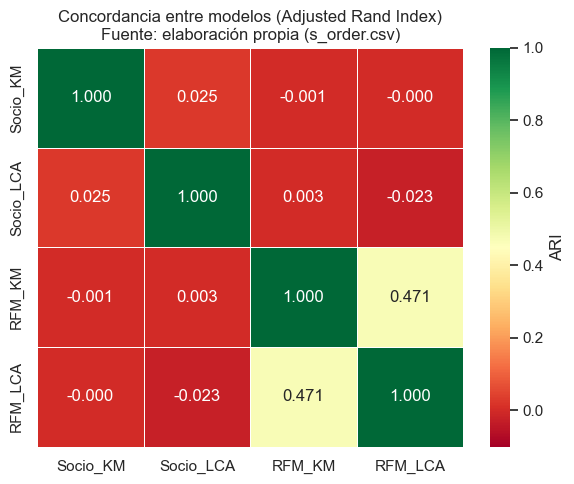

,Socio_KM,Socio_LCA,RFM_KM,RFM_LCA
Socio_KM,1.000,0.025,-0.001,-0.000
Socio_LCA,0.025,1.000,0.003,-0.023
RFM_KM,-0.001,0.003,1.000,0.471
RFM_LCA,-0.000,-0.023,0.471,1.000


In [15]:
# Concordancia entre modelos (Adjusted Rand Index)
modelos      = ['Cluster_Socio_KM', 'Cluster_Socio_LCA', 'Cluster_RFM_KM', 'Cluster_RFM_LCA']
nombres_cortos = ['Socio_KM', 'Socio_LCA', 'RFM_KM', 'RFM_LCA']
ari_matrix   = np.ones((4, 4))

for i, m1 in enumerate(modelos):
    for j, m2 in enumerate(modelos):
        if i != j:
            ari_matrix[i, j] = adjusted_rand_score(df_clientes[m1], df_clientes[m2])

ari_df = pd.DataFrame(ari_matrix, index=nombres_cortos, columns=nombres_cortos).round(3)

plt.figure(figsize=(6, 5))
sns.heatmap(ari_df, annot=True, cmap='RdYlGn', vmin=-0.1, vmax=1, fmt='.3f',
            linewidths=.5, cbar_kws={'label': 'ARI'})
plt.title('Concordancia entre modelos (Adjusted Rand Index)\nFuente: elaboración propia (s_order.csv)')
plt.tight_layout()
plt.show()
ari_df

Modelos más concordantes: RFM_KM vs RFM_LCA (ARI = 0.471)


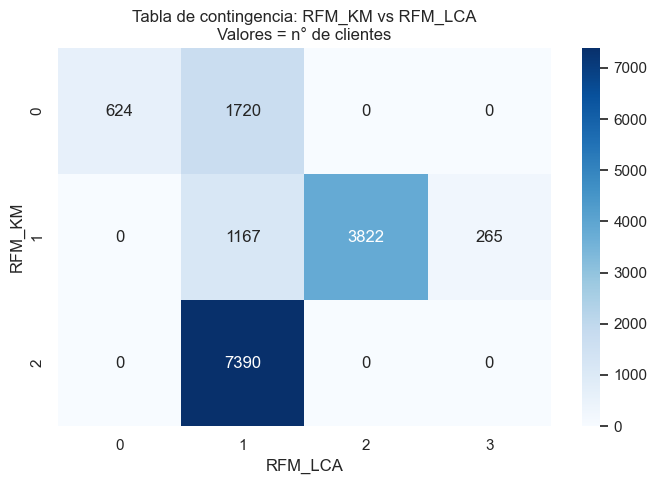

In [16]:
# Cross-tab entre los dos modelos más concordantes (sin la diaglonal obvio)
ari_off = ari_df.where(~np.eye(4, dtype=bool))
i_max, j_max = np.unravel_index(np.nanargmax(ari_off.values), ari_off.shape)
m1, m2 = nombres_cortos[i_max], nombres_cortos[j_max]
mod1_col, mod2_col = modelos[i_max], modelos[j_max]

print(f'Modelos más concordantes: {m1} vs {m2} (ARI = {ari_df.iloc[i_max, j_max]:.3f})')

ct = pd.crosstab(df_clientes[mod1_col], df_clientes[mod2_col],
                 rownames=[m1], colnames=[m2])
plt.figure(figsize=(7, 5))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.title(f'Tabla de contingencia: {m1} vs {m2}\nValores = n° de clientes')
plt.tight_layout()
plt.show()

In [17]:
# ==============================================================================
# PLANTILLAS INDEPENDIENTES DE PERFILAMIENTO: SOCIODEMOGRÁFICO Y RFM
# ==============================================================================
print("\n--- 1. Perfilamiento Dimensión Sociodemográfica (StepMix LCA) ---")

plantilla_socio = pd.DataFrame({
    'Cluster_LCA': sorted(df_clientes['Cluster_Socio_LCA'].unique()),
    'N clientes': df_clientes['Cluster_Socio_LCA'].value_counts().sort_index().values,
    '% base': (df_clientes['Cluster_Socio_LCA'].value_counts(normalize=True).sort_index() * 100).round(1).values,
    
    # Rellenado cualitativo basado en el output del modelo LCA
    'Variables que sobreindexan (>120)': [
        'Canal: Drive-Thru', 
        'Canal: Mobile App', 
        'Canal: In-Store'
    ],
    'Categorías dominantes': [
        '25-44 años', 
        '18-34 años', 
        '45+ años'
    ],
    'Nombre propuesto': [
        'Adultos Jóvenes Drive-Thru', 
        'Jóvenes Digitales', 
        'Tradicionales Presenciales'
    ]
})
display(plantilla_socio)


print("\n--- 2. Perfilamiento Dimensión Conductual (K-Means RFM) ---")

plantilla_rfm = pd.DataFrame({
    'Cluster_RFM': sorted(df_clientes['Cluster_RFM_KM'].unique()),
    'N clientes': df_clientes['Cluster_RFM_KM'].value_counts().sort_index().values,
    '% base': (df_clientes['Cluster_RFM_KM'].value_counts(normalize=True).sort_index() * 100).round(1).values,
    
    # Rellenado cualitativo basado en los promedios matemáticos del K-Means
    'Variables que sobreindexan (>120)': [
        'Recency', 
        'Monetary', 
        'Recency'
    ],
    'Categorías dominantes': [
        'Frecuencia', 
        'Recientes', 
        'Gasto medio'
    ],
    'Nombre propuesto': [
        'Dormidos', 
        'Leales Premium', 
        'Regulares Activos'
    ]
})
display(plantilla_rfm)


--- 1. Perfilamiento Dimensión Sociodemográfica (StepMix LCA) ---


,Cluster_LCA,N clientes,% base,Variables que sobreindexan (>120),Categorías dominantes,Nombre propuesto
0,0,2677,17.9,Canal: Drive-Thru,25-44 años,Adultos Jóvenes Drive-Thru
1,1,8951,59.7,Canal: Mobile App,18-34 años,Jóvenes Digitales
2,2,3360,22.4,Canal: In-Store,45+ años,Tradicionales Presenciales



--- 2. Perfilamiento Dimensión Conductual (K-Means RFM) ---


,Cluster_RFM,N clientes,% base,Variables que sobreindexan (>120),Categorías dominantes,Nombre propuesto
0,0,2344,15.6,Recency,Frecuencia,Dormidos
1,1,5254,35.1,Monetary,Recientes,Leales Premium
2,2,7390,49.3,Recency,Gasto medio,Regulares Activos


In [18]:
# Asignación de nombres a los segmentos
NOMBRES_RFM = {
    0: 'Dormidos',          
    1: 'Leales Premium',     
    2: 'Regulares Activos', } 


NOMBRES_SOCIO = {
    0: 'Adultos Drive-Thru',          
    1: 'Jóvenes Digitales',           
    2: 'Tradicionales Presenciales',  
}

# Aplicar nombres a las columnas para uso posterior
df_clientes['Nombre_RFM']   = df_clientes['Cluster_RFM_KM'].map(NOMBRES_RFM)
df_clientes['Nombre_Socio'] = df_clientes['Cluster_Socio_LCA'].map(NOMBRES_SOCIO)

# Etiqueta combinada (legible) para los 9 segmentos cruzados
df_clientes['Segmento_Nombre'] = (
    df_clientes['Nombre_Socio'] + ' · ' + df_clientes['Nombre_RFM']
)

print('Nombres asignados:')
print('\n  RFM:')
for k, v in NOMBRES_RFM.items():
    print(f'    Cluster {k} → {v}')
print('\n  Sociodemográfico:')
for k, v in NOMBRES_SOCIO.items():
    print(f'    Cluster {k} → {v}')

print('\nTamaño de cada uno de los 9 segmentos cruzados:')
tabla_seg = (df_clientes['Segmento_Nombre']
             .value_counts()
             .rename_axis('Segmento')
             .reset_index(name='N_clientes'))
tabla_seg['% mercado'] = (tabla_seg['N_clientes'] / len(df_clientes) * 100).round(1)
display(tabla_seg)


Nombres asignados:

  RFM:
    Cluster 0 → Dormidos
    Cluster 1 → Leales Premium
    Cluster 2 → Regulares Activos

  Sociodemográfico:
    Cluster 0 → Adultos Drive-Thru
    Cluster 1 → Jóvenes Digitales
    Cluster 2 → Tradicionales Presenciales

Tamaño de cada uno de los 9 segmentos cruzados:


,Segmento,N_clientes,% mercado
0,Jóvenes Digitales · Regulares Activos,4194,28.0
1,Jóvenes Digitales · Leales Premium,3461,23.1
2,Tradicionales Presenciales · Regulares Activos,1832,12.2
3,Adultos Drive-Thru · Regulares Activos,1364,9.1
4,Jóvenes Digitales · Dormidos,1296,8.6
5,Tradicionales Presenciales · Leales Premium,971,6.5
6,Adultos Drive-Thru · Leales Premium,822,5.5
7,Tradicionales Presenciales · Dormidos,557,3.7
8,Adultos Drive-Thru · Dormidos,491,3.3


Matriz de segmentos: Cluster_Socio_LCA × Cluster_RFM_KM


Total de segmentos posibles: 3 × 3 = 9
Segmentos con clientes: 9



,Segmento_Final,Cluster_Socio_LCA,Cluster_RFM_KM,N_clientes,Recency_media,Frequency_media,Monetary_media,% mercado
5,1_2,1,2,4194,76.62,5.48,84.15,28.0
4,1_1,1,1,3461,70.98,9.31,147.07,23.1
8,2_2,2,2,1832,74.72,5.60,74.38,12.2
2,0_2,0,2,1364,75.95,5.55,76.21,9.1
3,1_0,1,0,1296,301.47,4.22,65.94,8.6
7,2_1,2,1,971,67.40,9.61,133.87,6.5
1,0_1,0,1,822,71.33,9.55,135.05,5.5
6,2_0,2,0,557,290.57,4.21,55.72,3.7
0,0_0,0,0,491,292.10,4.02,54.98,3.3


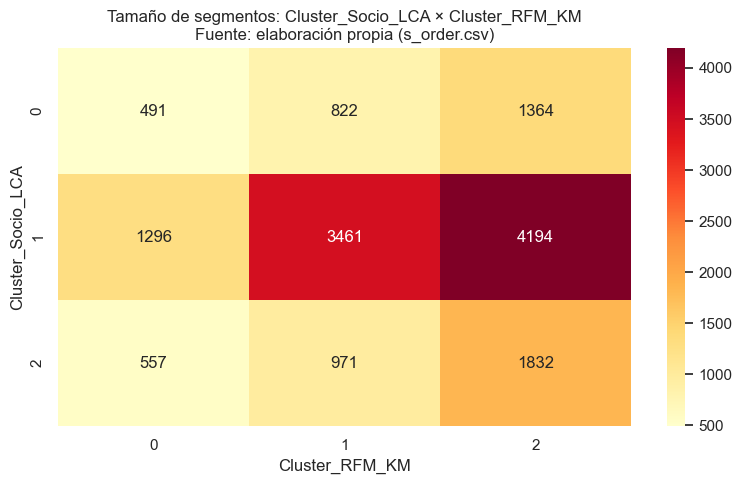

In [19]:
#Matrices de segmentos finales

col_socio = 'Cluster_Socio_LCA'   
col_rfm   = 'Cluster_RFM_KM'      

df_clientes['Segmento_Final'] = (
    df_clientes[col_socio].astype(str) + '_' +
    df_clientes[col_rfm].astype(str)
)

n_total = len(df_clientes)
resumen_segmentos = (df_clientes.groupby(['Segmento_Final', col_socio, col_rfm])
                      .agg(N_clientes=(col_socio, 'count'),
                           Recency_media=('Recency', 'mean'),
                           Frequency_media=('Frequency', 'mean'),
                           Monetary_media=('Monetary', 'mean'))
                      .reset_index())
resumen_segmentos['% mercado'] = (resumen_segmentos['N_clientes'] / n_total * 100).round(1)
resumen_segmentos = resumen_segmentos.sort_values('N_clientes', ascending=False).round(2)

print(f'Matriz de segmentos: {col_socio} × {col_rfm}')
print(f'Total de segmentos posibles: {df_clientes[col_socio].nunique()} × {df_clientes[col_rfm].nunique()} = '
      f'{df_clientes[col_socio].nunique() * df_clientes[col_rfm].nunique()}')
print(f'Segmentos con clientes: {df_clientes["Segmento_Final"].nunique()}\n')
display(resumen_segmentos)

# Heatmap de tamaño de segmentos
pivot_n = df_clientes.pivot_table(index=col_socio, columns=col_rfm,
                                   values='customer_id', aggfunc='count', fill_value=0)
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_n, annot=True, fmt='d', cmap='YlOrRd')
plt.title(f'Tamaño de segmentos: {col_socio} × {col_rfm}\nFuente: elaboración propia (s_order.csv)')
plt.tight_layout()
plt.show()

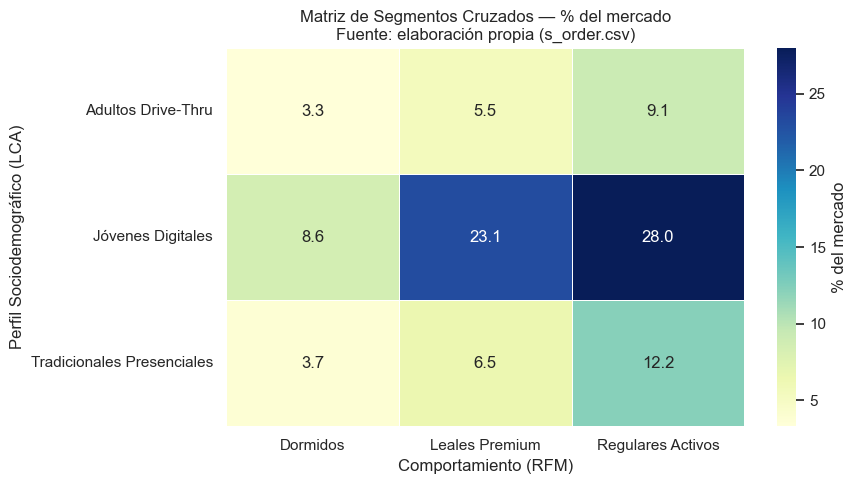

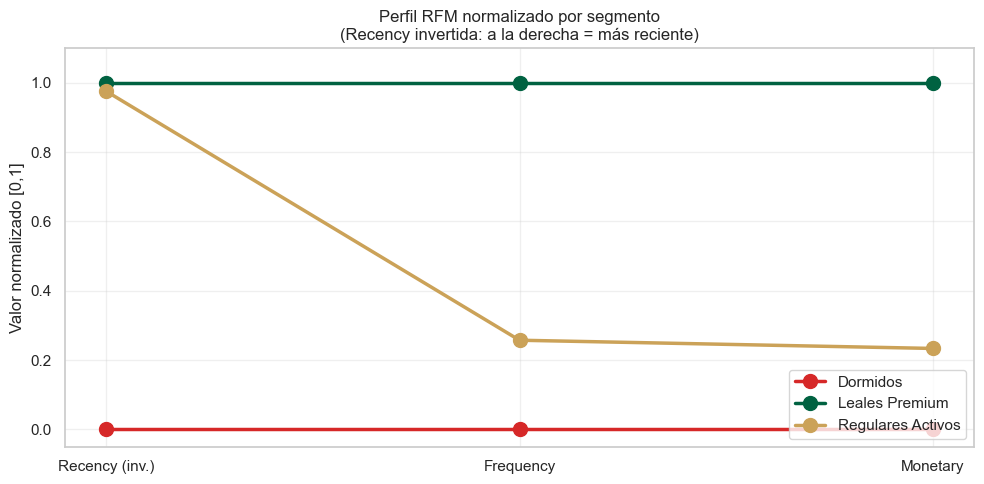


Valor monetario por segmento cruzado:


,N_clientes,Monetary_total,Monetary_promedio,% del revenue
Segmento_Nombre,,,,
Jóvenes Digitales · Leales Premium,3461,509019.71,147.07,34.2
Jóvenes Digitales · Regulares Activos,4194,352943.01,84.15,23.7
Tradicionales Presenciales · Regulares Activos,1832,136267.68,74.38,9.2
Tradicionales Presenciales · Leales Premium,971,129992.23,133.87,8.7
Adultos Drive-Thru · Leales Premium,822,111011.18,135.05,7.5
Adultos Drive-Thru · Regulares Activos,1364,103951.91,76.21,7.0
Jóvenes Digitales · Dormidos,1296,85456.99,65.94,5.7
Tradicionales Presenciales · Dormidos,557,31038.05,55.72,2.1
Adultos Drive-Thru · Dormidos,491,26996.32,54.98,1.8


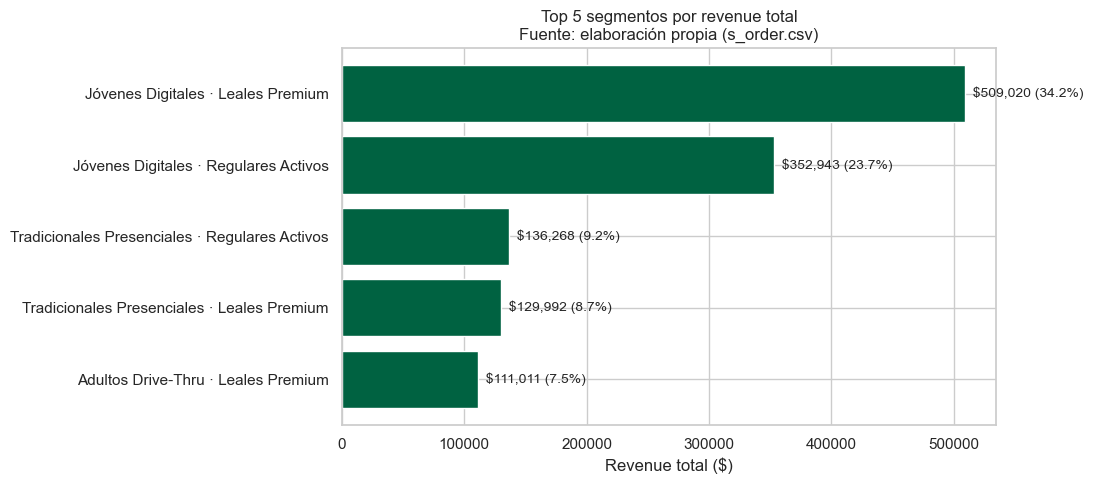

In [20]:
# Visualizaciones complementarias de los segmentos finales

#Heatmap de % de mercado por matriz cruzada (en lugar de N° absoluto)
pivot_pct = (df_clientes.pivot_table(
    index='Nombre_Socio', columns='Nombre_RFM',
    values='customer_id', aggfunc='count', fill_value=0) / len(df_clientes) * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot_pct, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': '% del mercado'},
            linewidths=0.5, ax=ax)
ax.set_title('Matriz de Segmentos Cruzados — % del mercado\nFuente: elaboración propia (s_order.csv)')
ax.set_xlabel('Comportamiento (RFM)')
ax.set_ylabel('Perfil Sociodemográfico (LCA)')
plt.tight_layout()
plt.show()

# Perfiles RFM normalizados (coordenadas paralelas)
perfil_rfm_norm = df_clientes.groupby('Nombre_RFM')[['Recency', 'Frequency', 'Monetary']].mean()

perfil_norm = perfil_rfm_norm.copy()
perfil_norm['Recency'] = (perfil_norm['Recency'].max() - perfil_norm['Recency']) / \
                        (perfil_norm['Recency'].max() - perfil_norm['Recency'].min())
perfil_norm['Frequency'] = (perfil_norm['Frequency'] - perfil_norm['Frequency'].min()) / \
                           (perfil_norm['Frequency'].max() - perfil_norm['Frequency'].min())
perfil_norm['Monetary'] = (perfil_norm['Monetary'] - perfil_norm['Monetary'].min()) / \
                          (perfil_norm['Monetary'].max() - perfil_norm['Monetary'].min())

fig, ax = plt.subplots(figsize=(10, 5))
colors_rfm = {'Dormidos': '#d62828', 'Regulares Activos': '#cba258', 'Leales Premium': '#006241'}
for nombre, fila in perfil_norm.iterrows():
    ax.plot(['Recency (inv.)', 'Frequency', 'Monetary'], fila.values,
            marker='o', markersize=10, linewidth=2.5,
            color=colors_rfm.get(nombre, 'gray'), label=nombre)
ax.set_title('Perfil RFM normalizado por segmento\n(Recency invertida: a la derecha = más reciente)')
ax.set_ylabel('Valor normalizado [0,1]')
ax.set_ylim(-0.05, 1.10)
ax.legend(loc='lower right', frameon=True)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Valor monetario total por segmento cruzado
valor_segmento = (df_clientes.groupby('Segmento_Nombre')
                  .agg(N_clientes=('customer_id', 'count'),
                       Monetary_total=('Monetary', 'sum'),
                       Monetary_promedio=('Monetary', 'mean'))
                  .sort_values('Monetary_total', ascending=False)
                  .round(2))
valor_segmento['% del revenue'] = (valor_segmento['Monetary_total'] /
                                    valor_segmento['Monetary_total'].sum() * 100).round(1)
print('\nValor monetario por segmento cruzado:')
display(valor_segmento)

top5 = valor_segmento.head(5)
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(top5.index[::-1], top5['Monetary_total'].values[::-1],
               color='#006241', edgecolor='white')
ax.set_title('Top 5 segmentos por revenue total\nFuente: elaboración propia (s_order.csv)')
ax.set_xlabel('Revenue total ($)')
for bar, val, pct in zip(bars, top5['Monetary_total'].values[::-1],
                          top5['% del revenue'].values[::-1]):
    ax.text(val, bar.get_y() + bar.get_height()/2, f'  ${val:,.0f} ({pct}%)',
            va='center', fontsize=10)
plt.tight_layout()
plt.show()



--- Perfilamiento Avanzado e Índices de Afinidad ---

Tabla de Perfilamiento e Índices de Afinidad (Base 100 = Promedio Poblacional):


,cart_size,customer_satisfaction,num_customizations,fulfillment_time_min,N_clientes,% mercado
Segmento_Final,,,,,,
1_2,101.1,100.9,108.8,101.8,4194,28.0
1_1,105.2,100.7,108.8,100.8,3461,23.1
2_2,93.3,98.9,83.8,91.0,1832,12.2
0_2,95.4,98.1,88.6,105.4,1364,9.1
1_0,103.3,101.5,111.4,103.0,1296,8.6
2_1,98.5,99.2,86.4,93.7,971,6.5
0_1,98.5,98.3,91.2,104.4,822,5.5
2_0,93.7,98.9,83.1,89.1,557,3.7
0_0,95.5,98.0,85.2,106.7,491,3.3


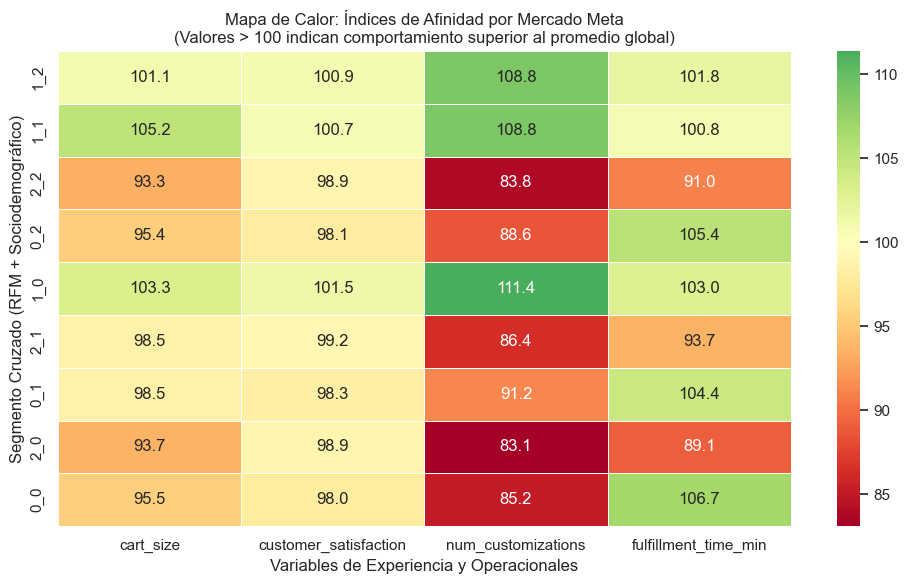

In [21]:
#Caracterización e índices de afinidad

print("\n--- Perfilamiento Avanzado e Índices de Afinidad ---")

# 1. Recuperar variables operacionales faltantes desde la base transaccional (df_cleaned)
df_extra = df_cleaned.groupby('customer_id').agg({
    'num_customizations': 'mean',
    'fulfillment_time_min': 'mean'
}).reset_index()

# Unir estas variables a df_clientes (solo si no están ya agregadas)
for col in ['num_customizations', 'fulfillment_time_min']:
    if col not in df_clientes.columns:
        df_clientes = df_clientes.merge(df_extra[['customer_id', col]], on='customer_id', how='left')

# 2. Crear la etiqueta 'Segmento_Final' cruzando RFM K-Means y Socio LCA
if 'Segmento_Final' not in df_clientes.columns:
    df_clientes['Segmento_Final'] = "RFM_" + df_clientes['Cluster_RFM_KM'].astype(str) + " + Socio_" + df_clientes['Cluster_Socio_LCA'].astype(str)

# 3. Definir columnas numéricas de interés para el perfilamiento
vars_perfilamiento = ['cart_size', 'customer_satisfaction', 'num_customizations', 'fulfillment_time_min']

# 4. Calcular promedios globales y promedios internos por segmento conjunto
promedios_globales = df_clientes[vars_perfilamiento].mean()
perfil_segmentos = df_clientes.groupby('Segmento_Final')[vars_perfilamiento].mean()

# 5. Calcular Índice de Afinidad ((Promedio Segmento / Promedio Global) * 100)
afinidad_segmentos = (perfil_segmentos / promedios_globales) * 100

# 6. Crear tabla de resumen incorporando Sustancialidad (N° de clientes)
conteo = df_clientes['Segmento_Final'].value_counts()
tabla_afinidad = afinidad_segmentos.copy().round(1)
tabla_afinidad['N_clientes'] = conteo
tabla_afinidad['% mercado'] = (conteo / len(df_clientes) * 100).round(1)

# Ordenar de mayor a menor para identificar fácilmente los mercados meta principales
tabla_afinidad = tabla_afinidad.sort_values(by='% mercado', ascending=False)

print("\nTabla de Perfilamiento e Índices de Afinidad (Base 100 = Promedio Poblacional):")
display(tabla_afinidad)

# 7. Visualización del Índice de Afinidad (Mapa de Calor)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(tabla_afinidad[vars_perfilamiento], annot=True, fmt=".1f", cmap="RdYlGn", center=100, linewidths=.5)
plt.title('Mapa de Calor: Índices de Afinidad por Mercado Meta\n(Valores > 100 indican comportamiento superior al promedio global)')
plt.ylabel('Segmento Cruzado (RFM + Sociodemográfico)')
plt.xlabel('Variables de Experiencia y Operacionales')
plt.tight_layout()
plt.show()

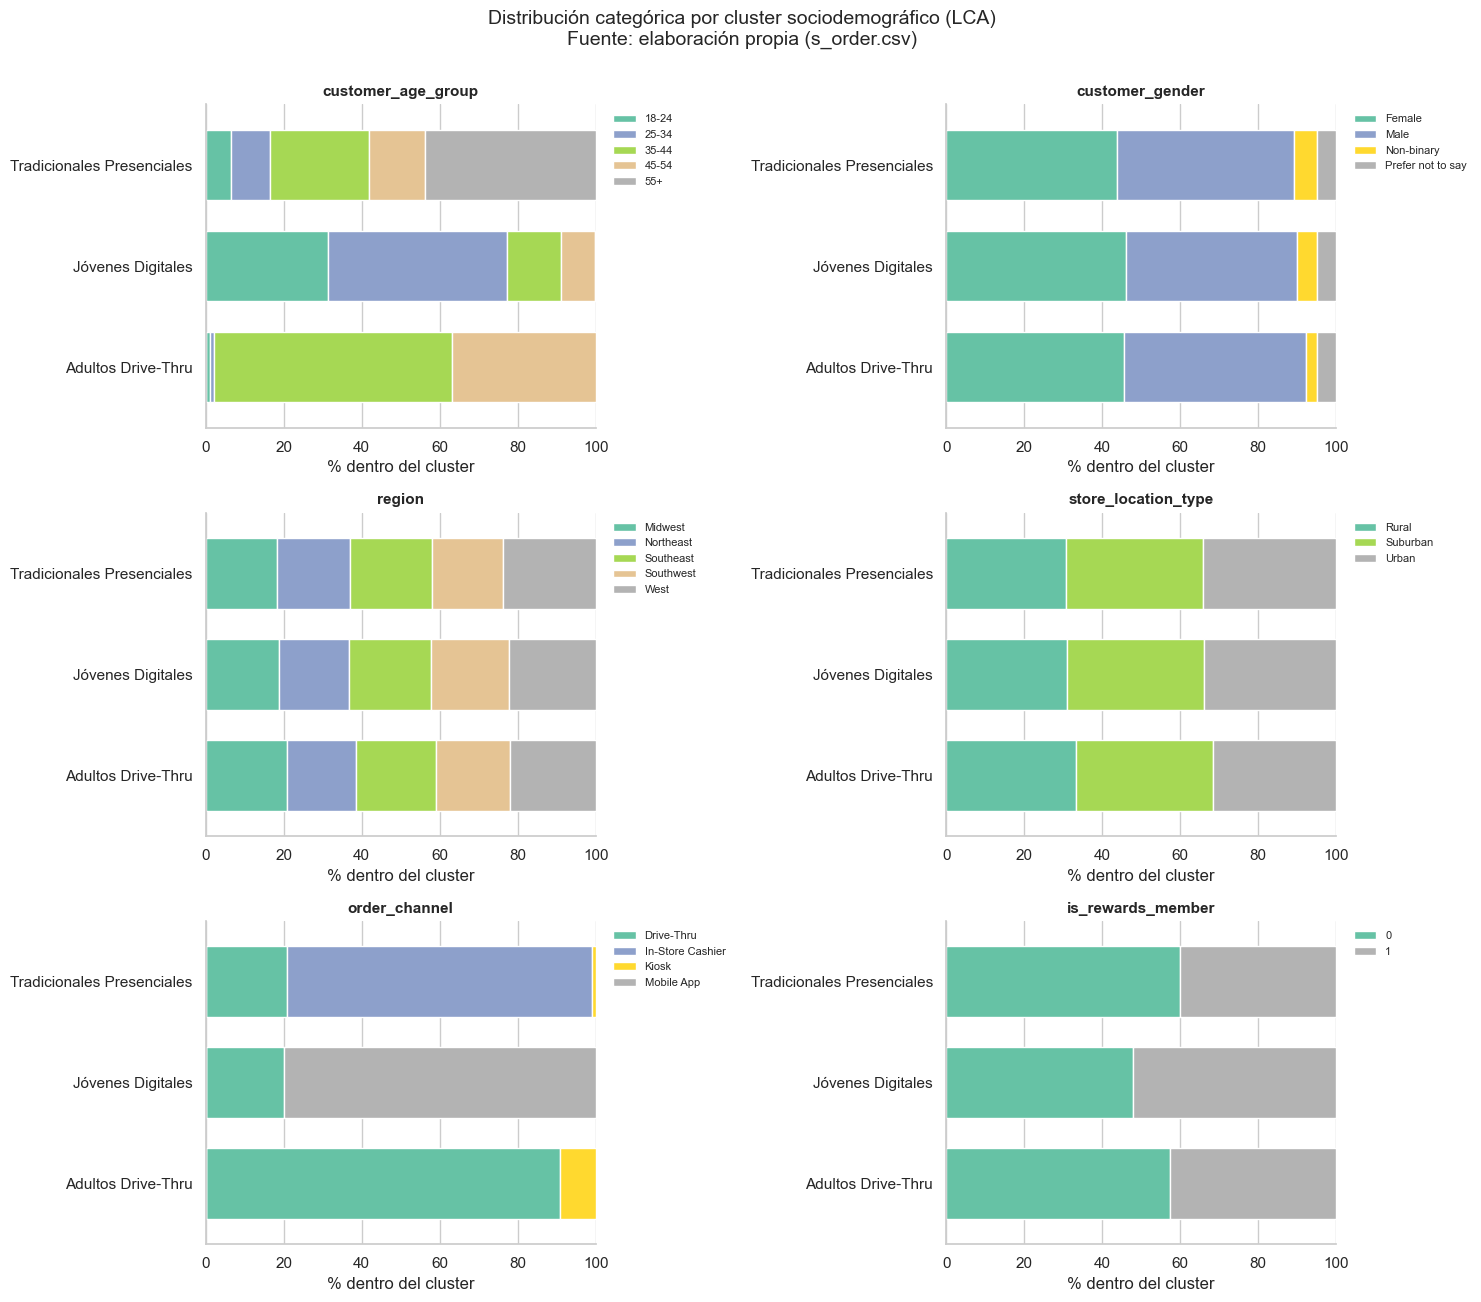

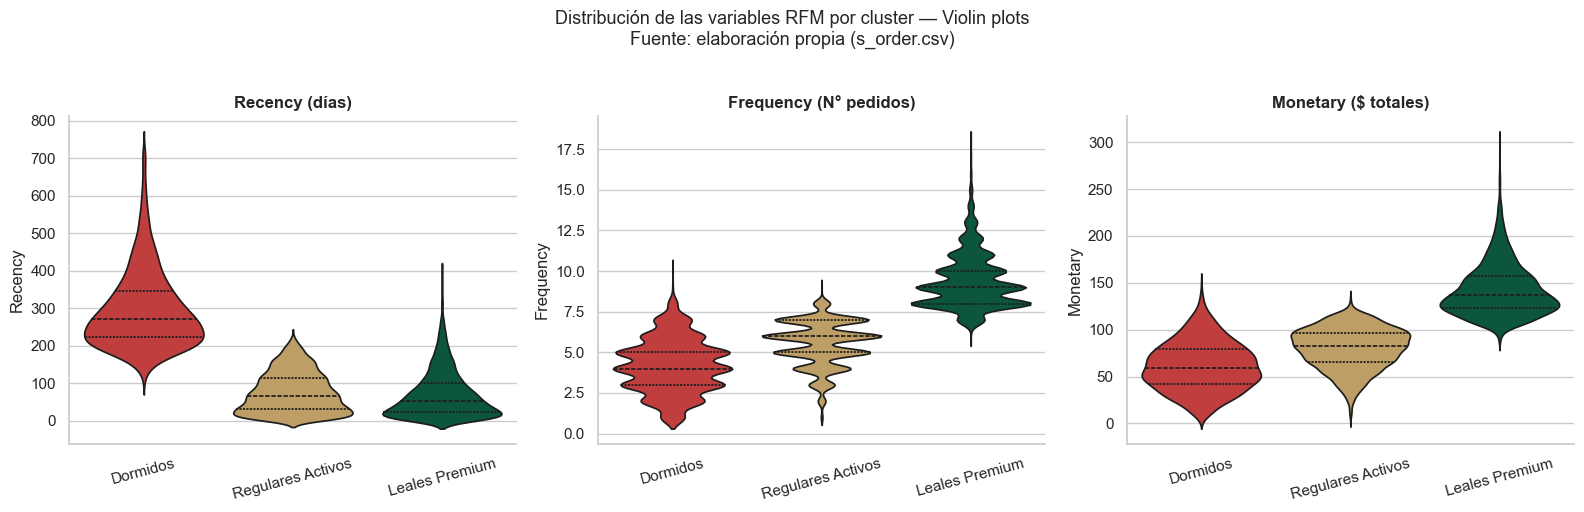

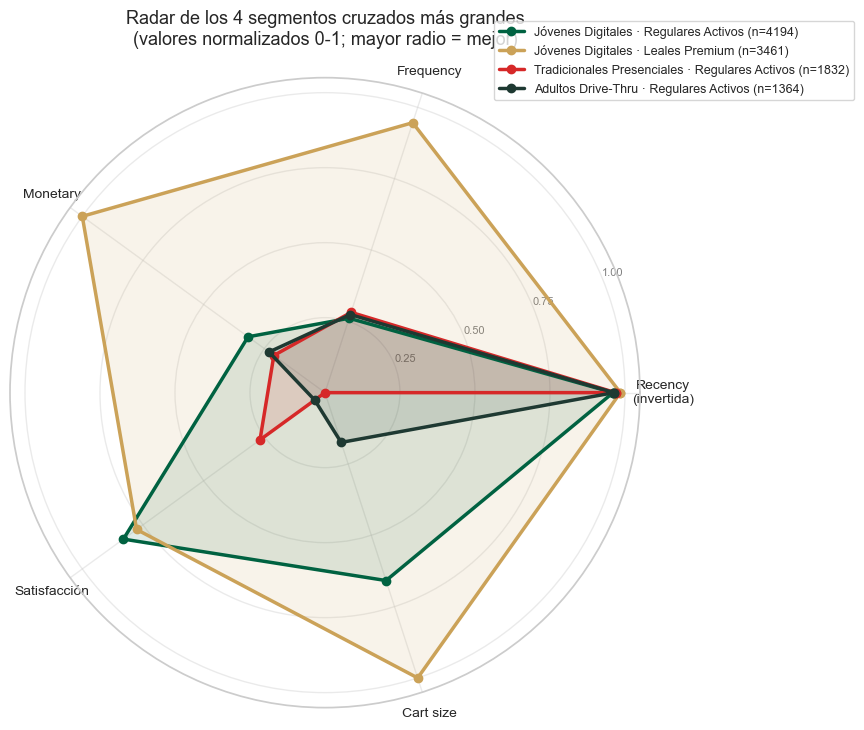

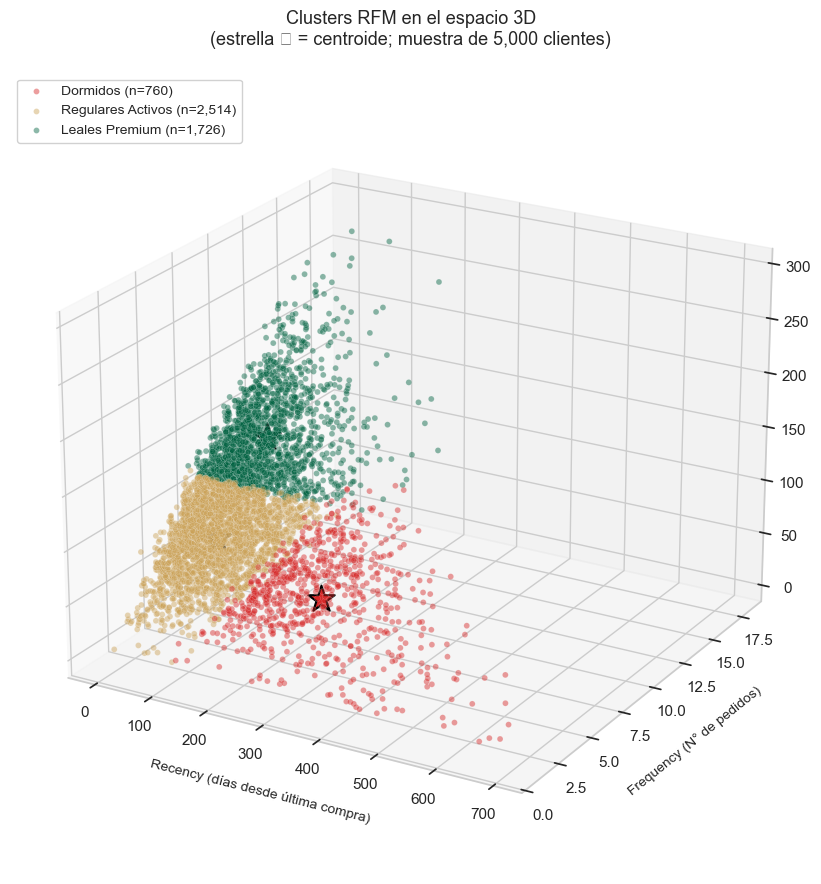


Visualizaciones complementarias generadas correctamente.


In [22]:
#Graficos complementarios de los clusters
from math import pi
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (necesario para 3D)

# Paleta consistente Starbucks
PAL_SOCIO = {'Adultos Drive-Thru': '#1e3932',
             'Jóvenes Digitales': '#006241',
             'Tradicionales Presenciales': '#cba258'}
PAL_RFM   = {'Dormidos': '#d62828',
             'Regulares Activos': '#cba258',
             'Leales Premium': '#006241'}

#Distribución categórica x cluster

vars_cat = ['customer_age_group', 'customer_gender', 'region',
            'store_location_type', 'order_channel', 'is_rewards_member']

fig, axes = plt.subplots(3, 2, figsize=(15, 13))
fig.suptitle('Distribución categórica por cluster sociodemográfico (LCA)\n'
             'Fuente: elaboración propia (s_order.csv)',
             fontsize=14, y=1.00)

for ax, var in zip(axes.flat, vars_cat):
    tabla = pd.crosstab(df_clientes['Nombre_Socio'], df_clientes[var],
                        normalize='index') * 100
    tabla.plot(kind='barh', stacked=True, ax=ax,
               colormap='Set2', edgecolor='white', width=0.7)
    ax.set_title(f'{var}', fontsize=11, fontweight='bold')
    ax.set_xlabel('% dentro del cluster')
    ax.set_ylabel('')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left',
              fontsize=8, frameon=False)
    ax.set_xlim(0, 100)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


#Violin plots 

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
vars_rfm = ['Recency', 'Frequency', 'Monetary']
unidades = ['(días)', '(N° pedidos)', '($ totales)']
orden_rfm = ['Dormidos', 'Regulares Activos', 'Leales Premium']

for ax, var, u in zip(axes, vars_rfm, unidades):
    sns.violinplot(data=df_clientes, x='Nombre_RFM', y=var,
                   order=orden_rfm, palette=PAL_RFM, inner='quartile',
                   ax=ax, hue='Nombre_RFM', legend=False)
    ax.set_title(f'{var} {u}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

fig.suptitle('Distribución de las variables RFM por cluster — Violin plots\n'
             'Fuente: elaboración propia (s_order.csv)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


#Radar chart

# Variables a comparar (mezcla RFM + experiencia)
vars_radar = ['Recency_inv', 'Frequency', 'Monetary',
              'customer_satisfaction', 'cart_size']

# Construir perfil promedio por segmento cruzado
perfil = (df_clientes.groupby('Segmento_Nombre')
          .agg(Recency=('Recency', 'mean'),
               Frequency=('Frequency', 'mean'),
               Monetary=('Monetary', 'mean'),
               customer_satisfaction=('customer_satisfaction', 'mean'),
               cart_size=('cart_size', 'mean'),
               N=('customer_id', 'count'))
          .copy())

# Recency invertida (menor = mejor → mayor en el radar)
perfil['Recency_inv'] = perfil['Recency'].max() - perfil['Recency']

# Normalización min-max para que todas las variables queden en [0,1]
perfil_norm = perfil[vars_radar].copy()
for v in vars_radar:
    rng = perfil_norm[v].max() - perfil_norm[v].min()
    perfil_norm[v] = (perfil_norm[v] - perfil_norm[v].min()) / (rng if rng > 0 else 1)

# Seleccionar top 4 segmentos por tamaño para que el radar sea legible
top_segs = perfil['N'].sort_values(ascending=False).head(4).index.tolist()

etiquetas = ['Recency\n(invertida)', 'Frequency', 'Monetary',
             'Satisfacción', 'Cart size']
N = len(etiquetas)
angulos = [n / float(N) * 2 * pi for n in range(N)]
angulos += angulos[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
colores_radar = ['#006241', '#cba258', '#d62828', '#1e3932']

for i, seg in enumerate(top_segs):
    valores = perfil_norm.loc[seg, vars_radar].tolist()
    valores += valores[:1]
    ax.plot(angulos, valores, marker='o', linewidth=2.5,
            color=colores_radar[i], label=f'{seg} (n={perfil.loc[seg, "N"]:.0f})')
    ax.fill(angulos, valores, alpha=0.12, color=colores_radar[i])

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(etiquetas, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=8, color='gray')
ax.set_title('Radar de los 4 segmentos cruzados más grandes\n'
             '(valores normalizados 0-1; mayor radio = mejor)',
             fontsize=13, pad=24)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.10), fontsize=9, frameon=True)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()


#Grafico 3d

# Muestreo para evitar saturación visual (5k puntos máximo)
sample_3d = df_clientes.sample(min(5000, len(df_clientes)), random_state=RANDOM_STATE)

fig = plt.figure(figsize=(13, 9))
ax = fig.add_subplot(111, projection='3d')

for nombre, color in PAL_RFM.items():
    sub = sample_3d[sample_3d['Nombre_RFM'] == nombre]
    ax.scatter(sub['Recency'], sub['Frequency'], sub['Monetary'],
               c=color, s=18, alpha=0.45, label=f'{nombre} (n={len(sub):,})',
               edgecolors='white', linewidths=0.2)

# Centroides resaltados
centroides = df_clientes.groupby('Nombre_RFM')[['Recency', 'Frequency', 'Monetary']].mean()
for nombre, fila in centroides.iterrows():
    ax.scatter(fila['Recency'], fila['Frequency'], fila['Monetary'],
               c=PAL_RFM[nombre], s=400, marker='*',
               edgecolors='black', linewidths=1.5, zorder=5)

ax.set_xlabel('Recency (días desde última compra)', fontsize=10, labelpad=10)
ax.set_ylabel('Frequency (N° de pedidos)', fontsize=10, labelpad=10)
ax.set_zlabel('Monetary ($ gastado)', fontsize=10, labelpad=10)
ax.set_title('Clusters RFM en el espacio 3D\n'
             '(estrella ★ = centroide; muestra de 5,000 clientes)',
             fontsize=13, pad=20)
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.view_init(elev=22, azim=-60)
plt.tight_layout()
plt.show()

print('\nVisualizaciones complementarias generadas correctamente.')


In [23]:
# ==============================================================================
# PLANTILLAS INDEPENDIENTES DE PERFILAMIENTO: SOCIODEMOGRÁFICO Y RFM
# ==============================================================================
print("\n--- 1. Perfilamiento Dimensión Sociodemográfica (StepMix LCA) ---")

plantilla_socio = pd.DataFrame({
    'Cluster_LCA': sorted(df_clientes['Cluster_Socio_LCA'].unique()),
    'N clientes': df_clientes['Cluster_Socio_LCA'].value_counts().sort_index().values,
    '% base': (df_clientes['Cluster_Socio_LCA'].value_counts(normalize=True).sort_index() * 100).round(1).values,
    
    # Rellenado cualitativo basado en el output del modelo LCA
    'Variables que sobreindexan (>120)': [
        'Canal: Drive-Thru', 
        'Canal: Mobile App', 
        'Canal: In-Store'
    ],
    'Categorías dominantes': [
        '25-44 años', 
        '18-34 años', 
        '45+ años'
    ],
    'Nombre propuesto': [
        'Adultos Jóvenes Drive-Thru', 
        'Jóvenes Digitales', 
        'Tradicionales Presenciales'
    ]
})
display(plantilla_socio)


print("\n--- 2. Perfilamiento Dimensión Conductual (K-Means RFM) ---")

plantilla_rfm = pd.DataFrame({
    'Cluster_RFM': sorted(df_clientes['Cluster_RFM_KM'].unique()),
    'N clientes': df_clientes['Cluster_RFM_KM'].value_counts().sort_index().values,
    '% base': (df_clientes['Cluster_RFM_KM'].value_counts(normalize=True).sort_index() * 100).round(1).values,
    
    # Rellenado cualitativo basado en los promedios matemáticos del K-Means
    'Variables que sobreindexan (>120)': [
        'Recency', 
        'Monetary', 
        'Recency'
    ],
    'Categorías dominantes': [
        'Frecuencia', 
        'Recientes', 
        'Gasto medio'
    ],
    'Nombre propuesto': [
        'Dormidos', 
        'Leales Premium', 
        'Regulares Activos'
    ]
})
display(plantilla_rfm)


--- 1. Perfilamiento Dimensión Sociodemográfica (StepMix LCA) ---


,Cluster_LCA,N clientes,% base,Variables que sobreindexan (>120),Categorías dominantes,Nombre propuesto
0,0,2677,17.9,Canal: Drive-Thru,25-44 años,Adultos Jóvenes Drive-Thru
1,1,8951,59.7,Canal: Mobile App,18-34 años,Jóvenes Digitales
2,2,3360,22.4,Canal: In-Store,45+ años,Tradicionales Presenciales



--- 2. Perfilamiento Dimensión Conductual (K-Means RFM) ---


,Cluster_RFM,N clientes,% base,Variables que sobreindexan (>120),Categorías dominantes,Nombre propuesto
0,0,2344,15.6,Recency,Frecuencia,Dormidos
1,1,5254,35.1,Monetary,Recientes,Leales Premium
2,2,7390,49.3,Recency,Gasto medio,Regulares Activos
